# Generative AI — Assignment No. 4
## Denoising Diffusion Probabilistic Model (DDPM)
### AI4009 | Spring 2026 | NUCES

**Dataset:** CelebA-HQ 256×256  
**Platform:** Kaggle (GPU T4 × 2)  
**Framework:** PyTorch (from scratch — no pretrained diffusion pipelines)

---
## CELL 1 — Install Dependencies

In [1]:
# ── Install extra packages not already on Kaggle ─────────────────────────────
!pip install -q scikit-image gradio

---
## CELL 2 — Imports & Device Setup

In [2]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image

from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device (supports dual T4) ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {device}')
if torch.cuda.is_available():
    print(f'GPU count    : {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}      : {torch.cuda.get_device_name(i)}')

Using device : cuda
GPU count    : 2
  GPU 0      : Tesla T4
  GPU 1      : Tesla T4


---
## CELL 3 — Hyperparameters & Config

In [3]:
# ── All tunable knobs in one place ────────────────────────────────────────────
IMG_SIZE    = 256          # 256×256 (recommended)
CHANNELS    = 3            # RGB
BATCH_SIZE  = 16           # fits on T4 × 2 with mixed precision
NUM_EPOCHS  = 20           # increase for better quality
LR          = 2e-4
TIMESTEPS   = 400          # 200-500 as instructed
BETA_START  = 1e-4
BETA_END    = 0.02
MODEL_CHANNELS = [64, 128, 256]   # U-Net channel progression

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/badasstechie/celebahq-resized-256x256/celeba_hq_256'
SAVE_DIR     = '/kaggle/working/outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Config set')

Config set


---
## CELL 4 — Explore Dataset

Total images found : 30000
Sample path        : /kaggle/input/datasets/badasstechie/celebahq-resized-256x256/celeba_hq_256/08450.jpg


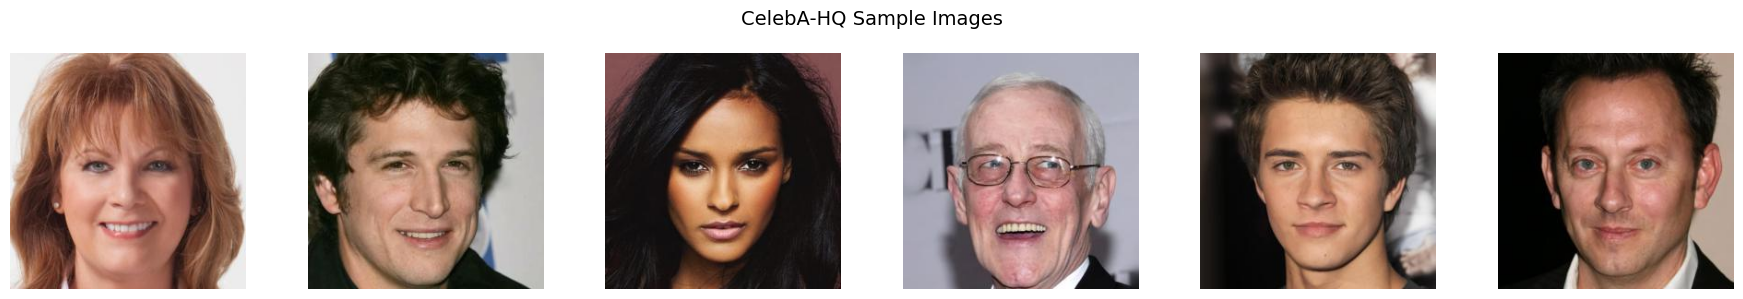

Dataset exploration done


In [4]:
# ── Peek at the dataset directory structure ───────────────────────────────────
dataset_root = Path(DATASET_PATH)
all_images   = list(dataset_root.rglob('*.jpg')) + \
               list(dataset_root.rglob('*.png')) + \
               list(dataset_root.rglob('*.jpeg'))

print(f'Total images found : {len(all_images)}')
print(f'Sample path        : {all_images[0]}')

# ── Show 6 random samples ─────────────────────────────────────────────────────
samples = random.sample(all_images, 6)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, p in zip(axes, samples):
    img = Image.open(p).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('CelebA-HQ Sample Images', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/dataset_samples.png', dpi=100)
plt.show()
print('Dataset exploration done')

---
## CELL 5 — Part 1: Data Preprocessing & DataLoader

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Custom Dataset
# ─────────────────────────────────────────────────────────────────────────────
class CelebAHQDataset(Dataset):
    """Loads CelebA-HQ images, resizes to IMG_SIZE×IMG_SIZE, normalises to [-1,1]."""
    def __init__(self, root_dir, img_size=256, max_images=None):
        self.root_dir   = Path(root_dir)
        self.img_size   = img_size
        self.image_paths = (
            list(self.root_dir.rglob('*.jpg'))  +
            list(self.root_dir.rglob('*.png'))  +
            list(self.root_dir.rglob('*.jpeg'))
        )
        if max_images:
            self.image_paths = self.image_paths[:max_images]

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size),
                              interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),                                   # [0, 1]
            transforms.Normalize(mean=[0.5, 0.5, 0.5],              # → [-1, 1]
                                 std =[0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)


# ─────────────────────────────────────────────────────────────────────────────
# Build DataLoader
# ─────────────────────────────────────────────────────────────────────────────
dataset    = CelebAHQDataset(DATASET_PATH, img_size=IMG_SIZE)
dataloader = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 4,
    pin_memory  = True,
    drop_last   = True
)

print(f'Dataset size   : {len(dataset)} images')
print(f'Batches/epoch  : {len(dataloader)}')
sample_batch = next(iter(dataloader))
print(f'Batch shape    : {sample_batch.shape}')   # (B, 3, 256, 256)
print(f'Value range    : [{sample_batch.min():.2f}, {sample_batch.max():.2f}]')

Dataset size   : 30000 images
Batches/epoch  : 1875
Batch shape    : torch.Size([16, 3, 256, 256])
Value range    : [-1.00, 1.00]


---
## CELL 6 — Part 2: Forward Diffusion (Noise Schedule + Noising Function)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Noise Schedule  (Linear beta schedule)
# ─────────────────────────────────────────────────────────────────────────────
class DiffusionSchedule:
    """
    Pre-computes all quantities derived from the beta schedule so that
    q(x_t | x_0) = N( sqrt(alpha_bar_t)*x0 ,  (1 - alpha_bar_t)*I )
    can be evaluated in O(1).
    """
    def __init__(self, timesteps=400, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T      = timesteps
        self.device = device

        # ── Linear schedule ─────────────────────────────────────────────────
        betas      = torch.linspace(beta_start, beta_end, timesteps, device=device)
        alphas     = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)            # ᾱ_t

        # ── Shift by one for reverse step convenience ──────────────────────
        alpha_bars_prev       = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

        # ── Store everything ────────────────────────────────────────────────
        self.betas            = betas
        self.alphas           = alphas
        self.alpha_bars       = alpha_bars
        self.alpha_bars_prev  = alpha_bars_prev
        self.sqrt_alpha_bars  = torch.sqrt(alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
        self.sqrt_recip_alphas         = torch.sqrt(1.0 / alphas)
        # Posterior variance: β̃_t = β_t * (1 - ᾱ_{t-1}) / (1 - ᾱ_t)
        self.posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

    def _gather(self, tensor, t, x_shape):
        """Gather values from a 1-D tensor using batch indices t."""
        vals = tensor[t]
        # reshape to (B, 1, 1, 1) for broadcasting
        return vals.view(t.shape[0], *((1,) * (len(x_shape) - 1)))

    # ── FORWARD (noising)  q(x_t | x_0) ─────────────────────────────────────
    def q_sample(self, x0, t):
        """
        Add noise to x0 at timestep t in one shot (closed-form).
        Returns: noisy image x_t  and  the noise epsilon that was added.
        """
        epsilon = torch.randn_like(x0)
        sqrt_ab = self._gather(self.sqrt_alpha_bars,           t, x0.shape)
        sqrt_1b = self._gather(self.sqrt_one_minus_alpha_bars, t, x0.shape)
        x_t     = sqrt_ab * x0 + sqrt_1b * epsilon
        return x_t, epsilon

    # ── REVERSE STEP  p(x_{t-1} | x_t) ──────────────────────────────────────
    @torch.no_grad()
    def p_sample(self, model, x_t, t_scalar):
        """
        Single denoising step; t_scalar is an integer (same for whole batch).
        """
        t_batch       = torch.full((x_t.shape[0],), t_scalar,
                                   device=x_t.device, dtype=torch.long)
        pred_noise    = model(x_t, t_batch)

        beta_t        = self._gather(self.betas,              t_batch, x_t.shape)
        sqrt_recip_a  = self._gather(self.sqrt_recip_alphas,  t_batch, x_t.shape)
        sqrt_1m_ab    = self._gather(self.sqrt_one_minus_alpha_bars, t_batch, x_t.shape)

        # Mean of reverse process
        model_mean    = sqrt_recip_a * (x_t - beta_t / sqrt_1m_ab * pred_noise)

        if t_scalar == 0:
            return model_mean

        post_var      = self._gather(self.posterior_variance, t_batch, x_t.shape)
        noise         = torch.randn_like(x_t)
        return model_mean + torch.sqrt(post_var) * noise

    # ── Full denoising loop (T → 0) ───────────────────────────────────────────
    @torch.no_grad()
    def p_sample_loop(self, model, shape, return_intermediates=False):
        """
        Generate images from pure noise by running the full reverse chain.
        If return_intermediates=True, also returns a list of intermediate images.
        """
        device    = self.device
        x         = torch.randn(shape, device=device)
        steps     = []
        capture   = set(np.linspace(0, self.T - 1, 6, dtype=int))  # 6 snapshots

        for t in tqdm(reversed(range(self.T)), total=self.T,
                      desc='Reverse diffusion', leave=False):
            x = self.p_sample(model, x, t)
            if return_intermediates and t in capture:
                steps.append(x.clone().cpu())

        if return_intermediates:
            return x.cpu(), steps
        return x.cpu()


# ── Instantiate schedule ──────────────────────────────────────────────────────
schedule = DiffusionSchedule(
    timesteps  = TIMESTEPS,
    beta_start = BETA_START,
    beta_end   = BETA_END,
    device     = device
)
print(f'Schedule ready — T={TIMESTEPS}')
print(f'beta range : {schedule.betas[0].item():.5f} → {schedule.betas[-1].item():.5f}')
print(f'alpha_bar at t=0   : {schedule.alpha_bars[0].item():.4f}')
print(f'alpha_bar at t=T-1 : {schedule.alpha_bars[-1].item():.4f}')

Schedule ready — T=400
beta range : 0.00010 → 0.02000
alpha_bar at t=0   : 0.9999
alpha_bar at t=T-1 : 0.0175


---
## CELL 7 — Visualise 5 Forward Diffusion Steps

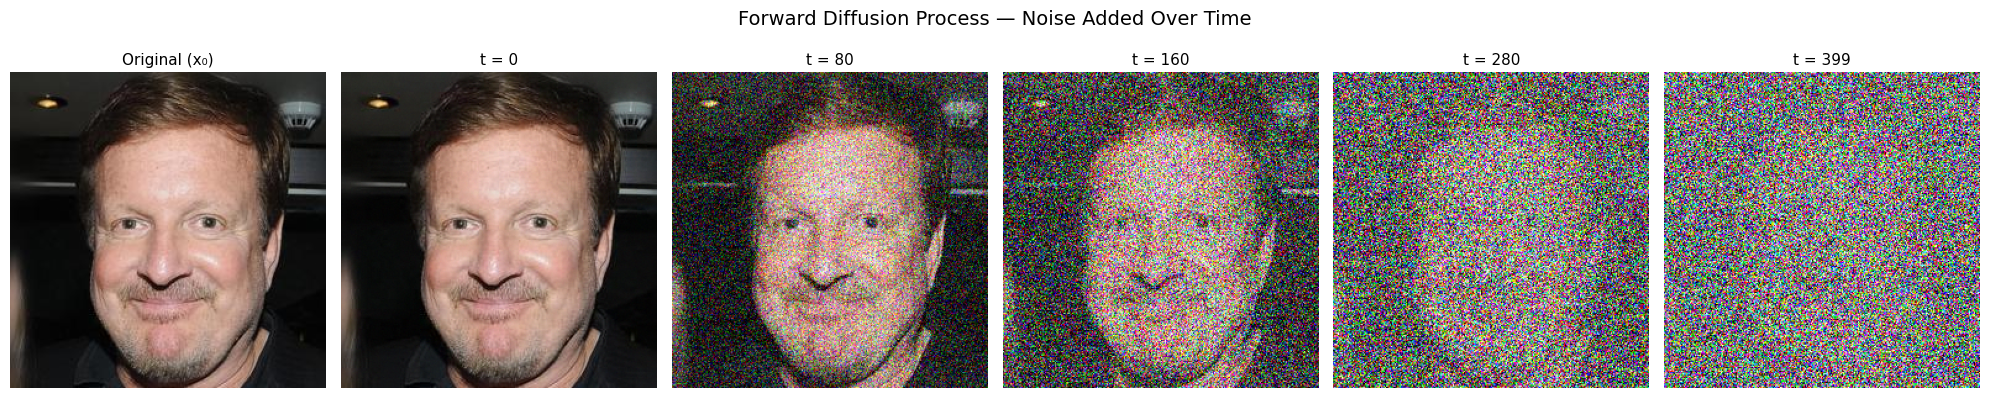

Forward diffusion visualisation saved


In [7]:
def tensor_to_pil(t):
    """Convert a normalised [-1,1] tensor (C,H,W) to a displayable numpy array [0,1]."""
    return ((t.clamp(-1, 1) + 1) / 2).permute(1, 2, 0).cpu().numpy()

# Pick one clean image from the first batch
x0_single = sample_batch[0].unsqueeze(0).to(device)   # (1, 3, 256, 256)

# Timesteps to visualise
vis_steps   = [0, int(TIMESTEPS*0.2), int(TIMESTEPS*0.4),
               int(TIMESTEPS*0.7), TIMESTEPS - 1]
step_labels = [f't = {s}' for s in vis_steps]

fig, axes = plt.subplots(1, len(vis_steps) + 1, figsize=(20, 4))

# Column 0 — original
axes[0].imshow(tensor_to_pil(x0_single[0]))
axes[0].set_title('Original (x₀)', fontsize=11)
axes[0].axis('off')

# Columns 1-5 — progressively noisier
for ax, step, label in zip(axes[1:], vis_steps, step_labels):
    t_tensor     = torch.tensor([step], device=device, dtype=torch.long)
    x_t, _       = schedule.q_sample(x0_single, t_tensor)
    ax.imshow(tensor_to_pil(x_t[0]))
    ax.set_title(label, fontsize=11)
    ax.axis('off')

plt.suptitle('Forward Diffusion Process — Noise Added Over Time', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/forward_diffusion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Forward diffusion visualisation saved')

---
## CELL 8 — Part 3: U-Net Architecture (from scratch)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper blocks
# ─────────────────────────────────────────────────────────────────────────────

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim * 4),
        )

    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None].float() * freq[None]
        emb  = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.mlp(emb)   # (B, dim*4)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()
        # Make sure in_ch and out_ch are divisible by groups
        g_in  = min(groups, in_ch)
        while in_ch  % g_in  != 0: g_in  -= 1
        g_out = min(groups, out_ch)
        while out_ch % g_out != 0: g_out -= 1

        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch))
        self.block1   = nn.Sequential(
            nn.GroupNorm(g_in,  in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        self.block2   = nn.Sequential(
            nn.GroupNorm(g_out, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, time_emb):
        h = self.block1(x)
        h = h + self.time_mlp(time_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class DownBlock(nn.Module):
    """ResBlock + strided-Conv downsampling. Returns (downsampled, skip)."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.res  = ResidualBlock(in_ch, out_ch, time_emb_dim)
        self.down = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t_emb):
        skip = self.res(x, t_emb)   # skip has `out_ch` channels
        out  = self.down(skip)
        return out, skip


class UpBlock(nn.Module):
    """
    TransposedConv upsample  →  concat skip  →  ResBlock.
    in_ch   : channels coming into this block from below
    skip_ch : channels of the skip connection from the encoder
    out_ch  : desired output channels
    """
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up  = nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1)
        # After concat, feature map has (out_ch + skip_ch) channels
        self.res = ResidualBlock(out_ch + skip_ch, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)                    # (B, out_ch, H*2, W*2)
        x = torch.cat([x, skip], dim=1)   # (B, out_ch + skip_ch, H*2, W*2)
        return self.res(x, t_emb)


# ─────────────────────────────────────────────────────────────────────────────
# U-Net  —  channel progression 64 → 128 → 256
# ─────────────────────────────────────────────────────────────────────────────
# Encoder skip-channel sizes:
#   down1 skip → chs[0] = 64
#   down2 skip → chs[1] = 128
#   down3 skip → chs[2] = 256
#
# Decoder channel math:
#   up3 : in=chs[2]=256, skip=chs[2]=256, out=chs[1]=128  → ResBlock(384, 128)
#   up2 : in=chs[1]=128, skip=chs[1]=128, out=chs[0]=64   → ResBlock(192, 64)
#   up1 : in=chs[0]=64,  skip=chs[0]=64,  out=chs[0]=64   → ResBlock(128, 64)
# ─────────────────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_ch=3, model_ch=64, out_ch=3, ch_mult=(1, 2, 4)):
        super().__init__()
        time_dim = model_ch * 4
        chs      = [model_ch * m for m in ch_mult]   # [64, 128, 256]

        # Time embedding
        self.time_embedding = SinusoidalTimeEmbedding(model_ch)

        # Encoder
        self.conv_in = nn.Conv2d(in_ch, chs[0], 3, padding=1)
        self.down1   = DownBlock(chs[0], chs[0], time_dim)   # skip: 64
        self.down2   = DownBlock(chs[0], chs[1], time_dim)   # skip: 128
        self.down3   = DownBlock(chs[1], chs[2], time_dim)   # skip: 256

        # Bottleneck
        self.mid1 = ResidualBlock(chs[2], chs[2], time_dim)
        self.mid2 = ResidualBlock(chs[2], chs[2], time_dim)

        # Decoder  (in_ch, skip_ch, out_ch, time_dim)
        self.up3 = UpBlock(chs[2], chs[2], chs[1], time_dim)  # 256,256→128
        self.up2 = UpBlock(chs[1], chs[1], chs[0], time_dim)  # 128,128→64
        self.up1 = UpBlock(chs[0], chs[0], chs[0], time_dim)  #  64, 64→64

        # Output head
        self.out_norm = nn.GroupNorm(8, chs[0])
        self.out_conv = nn.Conv2d(chs[0], out_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)         # (B, time_dim)

        # Encoder
        x      = self.conv_in(x)               # (B, 64,  H,   W)
        x, s1  = self.down1(x,  t_emb)         # (B, 64,  H/2, W/2)
        x, s2  = self.down2(x,  t_emb)         # (B, 128, H/4, W/4)
        x, s3  = self.down3(x,  t_emb)         # (B, 256, H/8, W/8)

        # Bottleneck
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        # Decoder
        x = self.up3(x, s3, t_emb)             # (B, 128, H/4, W/4)
        x = self.up2(x, s2, t_emb)             # (B, 64,  H/2, W/2)
        x = self.up1(x, s1, t_emb)             # (B, 64,  H,   W)

        # Head
        x = F.silu(self.out_norm(x))
        return self.out_conv(x)                # (B, 3, H, W)


# ── Instantiate & wrap in DataParallel for T4 × 2 ───────────────────────────
model = UNet(in_ch=CHANNELS, out_ch=CHANNELS)
if torch.cuda.device_count() > 1:
    print(f'Using DataParallel on {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'U-Net built  |  Parameters: {total_params/1e6:.2f} M')

# Quick shape test
with torch.no_grad():
    dummy_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device)
    dummy_t = torch.randint(0, TIMESTEPS, (2,), device=device)
    dummy_y = model(dummy_x, dummy_t)
    print(f'Test forward pass  in:{list(dummy_x.shape)}  out:{list(dummy_y.shape)}')

Using DataParallel on 2 GPUs
U-Net built  |  Parameters: 7.00 M
Test forward pass  in:[2, 3, 256, 256]  out:[2, 3, 256, 256]


---
## CELL 9 — Part 4: Training Setup (Loss, Optimizer, Scheduler, Mixed Precision)

In [9]:
# ── Loss function ─────────────────────────────────────────────────────────────
loss_fn   = nn.MSELoss()                              # compare predicted vs actual noise

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# ── Cosine LR scheduler ───────────────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# ── Mixed precision scaler (for T4) ───────────────────────────────────────────
scaler    = torch.amp.GradScaler('cuda')

print(f'Optimizer : AdamW  lr={LR}')
print(f'Scheduler : CosineAnnealing  T_max={NUM_EPOCHS}')
print(f'AMP scaler ready')

Optimizer : AdamW  lr=0.0002
Scheduler : CosineAnnealing  T_max=20
AMP scaler ready


---
## CELL 10 — Training Loop

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Training Config
# ─────────────────────────────────────────────────────────────────────────────
# Reset AMP scaler — prevents "unscale_ already called" if cell is re-run
scaler = torch.amp.GradScaler('cuda')

CHECKPOINT_DIR    = f'{SAVE_DIR}/checkpoints'
CHECKPOINT_DIR    = f'{SAVE_DIR}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SAVE_EVERY        = 3      # save a checkpoint every N epochs
EARLY_STOP_PAT    = 5     # stop if no improvement for this many epochs
RESUME            = True   # set to False to start fresh

CHECKPOINT_PATH   = f'{CHECKPOINT_DIR}/last_checkpoint.pth'
BEST_MODEL_PATH   = f'{SAVE_DIR}/ddpm_best.pth'

# ─────────────────────────────────────────────────────────────────────────────
# Checkpoint helpers
# ─────────────────────────────────────────────────────────────────────────────
def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    train_losses, best_loss, path):
    torch.save({
        'epoch'         : epoch,
        'model_state'   : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'scaler_state'  : scaler.state_dict(),
        'train_losses'  : train_losses,
        'best_loss'     : best_loss,
    }, path)
    print(f'  Checkpoint saved → {path}')


def load_checkpoint(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    scaler.load_state_dict(ckpt['scaler_state'])
    print(f'  Resumed from epoch {ckpt["epoch"]}  |  Best loss so far: {ckpt["best_loss"]:.6f}')
    return ckpt['epoch'], ckpt['train_losses'], ckpt['best_loss']


# ─────────────────────────────────────────────────────────────────────────────
# Resume or start fresh
# ─────────────────────────────────────────────────────────────────────────────
train_losses  = []
best_loss     = float('inf')
start_epoch   = 1
no_improve    = 0          # early stopping counter

if RESUME and os.path.exists(CHECKPOINT_PATH):
    start_epoch, train_losses, best_loss = load_checkpoint(
        CHECKPOINT_PATH, model, optimizer, scheduler, scaler
    )
    start_epoch += 1       # resume from NEXT epoch
    no_improve   = 0
else:
    print('Starting fresh training...')

print(f'\nTraining from epoch {start_epoch} → {NUM_EPOCHS}')
print(f'Early stopping patience : {EARLY_STOP_PAT} epochs')
print(f'Checkpoint every        : {SAVE_EVERY} epochs\n')

# ─────────────────────────────────────────────────────────────────────────────
# Training Loop
# ─────────────────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):

    model.train()
    epoch_loss = 0.0

    progress = tqdm(dataloader, desc=f'Epoch {epoch:02d}/{NUM_EPOCHS}', leave=False)

    for batch in progress:
        x0 = batch.to(device)

        # Random timesteps
        t  = torch.randint(0, TIMESTEPS, (x0.shape[0],),
                           device=device, dtype=torch.long)

        # Forward (noising)
        x_t, noise = schedule.q_sample(x0, t)

        # Mixed-precision forward
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            pred_noise = model(x_t, t)
            loss       = loss_fn(pred_noise, noise)

        # Backward + gradient clip
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        progress.set_postfix(loss=f'{loss.item():.4f}')

    # ── End of epoch ──────────────────────────────────────────────────────────
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    scheduler.step()

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  |  '
          f'Loss: {avg_loss:.6f}  |  '
          f'LR: {scheduler.get_last_lr()[0]:.2e}  |  '
          f'No-improve: {no_improve}/{EARLY_STOP_PAT}')

    # ── Save best model ───────────────────────────────────────────────────────
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  New best loss: {best_loss:.6f} — best model saved')
    else:
        no_improve += 1

    # ── Periodic checkpoint (every SAVE_EVERY epochs) ─────────────────────────
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        train_losses, best_loss, CHECKPOINT_PATH)
        # Also save a timestamped copy so you never overwrite a good one
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        train_losses, best_loss,
                        f'{CHECKPOINT_DIR}/epoch_{epoch:03d}.pth')

    # ── Early stopping ────────────────────────────────────────────────────────
    if no_improve >= EARLY_STOP_PAT:
        print(f'\nEarly stopping triggered — no improvement for {EARLY_STOP_PAT} epochs')
        # Save final state before stopping
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        train_losses, best_loss, CHECKPOINT_PATH)
        break

# ── Always save last state when loop ends ────────────────────────────────────
else:
    save_checkpoint(NUM_EPOCHS, model, optimizer, scheduler, scaler,
                    train_losses, best_loss, CHECKPOINT_PATH)

print(f'\nTraining done ✓  |  Best loss: {best_loss:.6f}')
torch.save(model.state_dict(), f'{SAVE_DIR}/ddpm_final.pth')

Starting fresh training...

Training from epoch 1 → 20
Early stopping patience : 5 epochs
Checkpoint every        : 3 epochs



Epoch 01/20:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 01/20  |  Loss: 0.034826  |  LR: 1.99e-04  |  No-improve: 0/5
  New best loss: 0.034826 — best model saved


Epoch 02/20:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 02/20  |  Loss: 0.018963  |  LR: 1.95e-04  |  No-improve: 0/5
  New best loss: 0.018963 — best model saved


...

Epoch 11/20:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 11/20  |  Loss: 0.014313  |  LR: 8.49e-05  |  No-improve: 1/5
  New best loss: 0.014313 — best model saved


Epoch 12/20:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 12/20  |  Loss: 0.014158  |  LR: 6.98e-05  |  No-improve: 0/5
  New best loss: 0.014158 — best model saved
  Checkpoint saved → /kaggle/working/outputs/checkpoints/last_checkpoint.pth
  Checkpoint saved → /kaggle/working/outputs/checkpoints/epoch_012.pth


Epoch 13/20:   0%|          | 0/1875 [00:00<?, ?it/s]

---
## CELL 11 — Training Loss Plot

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses,
         color='royalblue', linewidth=2, label='Train Loss (MSE)')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MSE Loss', fontsize=13)
plt.title('DDPM Training Loss vs Epochs', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/loss_curve.png', dpi=120)
plt.show()
print(f'Loss curve saved  |  Final loss: {train_losses[-1]:.6f}')

---
## CELL 12 — Load Best Checkpoint for Inference

In [ ]:
# ── Load the best saved weights ───────────────────────────────────────────────
model.load_state_dict(torch.load(f'{SAVE_DIR}/ddpm_best.pth', map_location=device))
model.eval()
print('Best checkpoint loaded')

---
## CELL 13 — Part 5: Image Generation (5 New Images from Pure Noise)

In [ ]:
# ── Generate 5 new images from pure Gaussian noise ───────────────────────────
NUM_GEN = 5
gen_shape = (NUM_GEN, CHANNELS, IMG_SIZE, IMG_SIZE)

print(f'Generating {NUM_GEN} images from pure noise...')
generated_images = schedule.p_sample_loop(model, gen_shape)   # (5, 3, H, W)

# ── Display ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_GEN, figsize=(20, 4))
for i, ax in enumerate(axes):
    ax.imshow(tensor_to_pil(generated_images[i]))
    ax.set_title(f'Generated #{i+1}', fontsize=11)
    ax.axis('off')

plt.suptitle('Images Generated from Pure Noise — DDPM', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/generated_images.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Save individual files ─────────────────────────────────────────────────────
for i, img_t in enumerate(generated_images):
    img_np  = (tensor_to_pil(img_t) * 255).astype(np.uint8)
    Image.fromarray(img_np).save(f'{SAVE_DIR}/gen_{i+1}.png')

print(f'{NUM_GEN} generated images saved ✓')

---
## CELL 14 — Part 5: Image Reconstruction (Target → Reconstruct via Reverse Diffusion)

In [ ]:
# ── Pick a target image (use first image from dataset) ───────────────────────
target_tensor = dataset[0].unsqueeze(0).to(device)   # (1, 3, 256, 256)
target_np     = tensor_to_pil(target_tensor[0])      # H×W×3 in [0,1]

# ── Add noise up to a mid-point then reconstruct ─────────────────────────────
# Strategy: noise image to t=T-1 then fully denoise
t_noise = torch.tensor([TIMESTEPS - 1], device=device, dtype=torch.long)
x_noised, _ = schedule.q_sample(target_tensor, t_noise)    # fully noised

# ── Run the reverse loop starting from the noised image ──────────────────────
print('Running reconstruction via reverse diffusion...')
x = x_noised.clone()
recon_steps = []
capture_at  = set(np.linspace(0, TIMESTEPS - 1, 5, dtype=int))

for t_idx in tqdm(reversed(range(TIMESTEPS)), total=TIMESTEPS,
                  desc='Reconstructing'):
    x = schedule.p_sample(model, x, t_idx)
    if t_idx in capture_at:
        recon_steps.append(x.clone().cpu())

reconstructed_tensor = x.cpu()
recon_np             = tensor_to_pil(reconstructed_tensor[0])

# ── Save reconstructed image ──────────────────────────────────────────────────
Image.fromarray((recon_np * 255).astype(np.uint8)).save(
    f'{SAVE_DIR}/reconstructed.png')
Image.fromarray((target_np * 255).astype(np.uint8)).save(
    f'{SAVE_DIR}/target.png')

# ── Side-by-side comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_np);                        axes[0].set_title('Target (Original)', fontsize=12)
axes[1].imshow(tensor_to_pil(x_noised[0].cpu())); axes[1].set_title('Fully Noised Input', fontsize=12)
axes[2].imshow(recon_np);                         axes[2].set_title('Reconstructed Output', fontsize=12)
for ax in axes: ax.axis('off')
plt.suptitle('Image Reconstruction: Target vs Generated', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/reconstruction_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Reconstruction complete')

---
## CELL 15 — Visualise 5 Reverse Diffusion (Denoising) Steps

In [ ]:
# recon_steps was collected during reconstruction above (5 snapshots)
labels = ['Pure Noise', 'Step 1', 'Step 2', 'Step 3', 'Denoised']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, step_tensor, label in zip(axes, recon_steps, labels):
    ax.imshow(tensor_to_pil(step_tensor[0]))
    ax.set_title(label, fontsize=11)
    ax.axis('off')

plt.suptitle('Reverse Diffusion Process — Denoising Steps', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/reverse_diffusion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Reverse diffusion visualisation saved')

---
## CELL 16 — Part 4 (Deliverable): Quantitative Evaluation — PSNR & SSIM

In [ ]:
# ── Compute PSNR and SSIM between target and reconstructed ───────────────────
target_eval = (target_np * 255).astype(np.uint8).astype(np.float32) / 255.0
recon_eval  = (recon_np  * 255).astype(np.uint8).astype(np.float32) / 255.0

# PSNR
psnr_score = psnr_fn(target_eval, recon_eval, data_range=1.0)

# SSIM  (channel_axis=2 for H×W×C images)
ssim_score = ssim_fn(
    target_eval, recon_eval,
    channel_axis=2,
    data_range=1.0
)

print('=' * 40)
print(f'  PSNR : {psnr_score:.4f} dB')
print(f'  SSIM : {ssim_score:.4f}')
print('=' * 40)
print('  PSNR > 20 dB  → acceptable quality')
print('  SSIM > 0.5    → good structural similarity')

# ── Also compute per generated image vs a second dataset sample ───────────────
print('\nPer-generated-image scores (vs dataset sample):')
ref_img = tensor_to_pil(dataset[1])  # reference
ref_img = (ref_img * 255).astype(np.uint8).astype(np.float32) / 255.0

for i, img_t in enumerate(generated_images):
    gen_img = tensor_to_pil(img_t)
    gen_img = (gen_img * 255).astype(np.uint8).astype(np.float32) / 255.0
    p = psnr_fn(ref_img, gen_img, data_range=1.0)
    s = ssim_fn(ref_img, gen_img, channel_axis=2, data_range=1.0)
    print(f'  Image {i+1}: PSNR={p:.2f} dB  |  SSIM={s:.4f}')

---
## CELL 17 — Full Visualisation Module (Summary Grid)

In [ ]:
# ── Master visualisation: all results in one figure ──────────────────────────
fig = plt.figure(figsize=(22, 14))
fig.suptitle('DDPM — Complete Results Summary', fontsize=18, fontweight='bold', y=1.01)

# ── Row 1: Forward diffusion (original + 5 noisy) ────────────────────────────
row1_images = [tensor_to_pil(x0_single[0])]
for step in vis_steps:
    t_t = torch.tensor([step], device=device, dtype=torch.long)
    xt, _ = schedule.q_sample(x0_single, t_t)
    row1_images.append(tensor_to_pil(xt[0]))
row1_titles = ['Original'] + [f't={s}' for s in vis_steps]

for j, (im, tl) in enumerate(zip(row1_images, row1_titles)):
    ax = fig.add_subplot(3, 6, j + 1)
    ax.imshow(im); ax.set_title(tl, fontsize=9); ax.axis('off')

# ── Row 2: Reverse diffusion steps ───────────────────────────────────────────
for j, (step_t, lbl) in enumerate(zip(recon_steps, labels)):
    ax = fig.add_subplot(3, 6, 7 + j)
    ax.imshow(tensor_to_pil(step_t[0]))
    ax.set_title(lbl, fontsize=9)
    ax.axis('off')

# Fill remaining column of row 2 with reconstructed
ax = fig.add_subplot(3, 6, 12)
ax.imshow(recon_np); ax.set_title('Reconstructed', fontsize=9); ax.axis('off')

# ── Row 3: 5 generated images ─────────────────────────────────────────────────
for j, img_t in enumerate(generated_images):
    ax = fig.add_subplot(3, 6, 13 + j)
    ax.imshow(tensor_to_pil(img_t))
    ax.set_title(f'Generated {j+1}', fontsize=9)
    ax.axis('off')

# ── Target vs Reconstructed comparison in col 6 row 3 ────────────────────────
ax = fig.add_subplot(3, 6, 18)
ax.imshow(target_np); ax.set_title('Target', fontsize=9); ax.axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/full_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Full summary grid saved ✓')

---
## CELL 18 — Gradio App Deployment

In [ ]:
import gradio as gr

# ── Inference helpers ─────────────────────────────────────────────────────────
def gradio_generate():
    """Generate one image from pure noise and return it + 5 denoising snapshots."""
    model.eval()
    shape = (1, CHANNELS, IMG_SIZE, IMG_SIZE)

    x      = torch.randn(shape, device=device)
    steps  = []
    capture = set(np.linspace(0, TIMESTEPS - 1, 5, dtype=int))

    with torch.no_grad():
        for t_idx in reversed(range(TIMESTEPS)):
            x = schedule.p_sample(model, x, t_idx)
            if t_idx in capture:
                steps.append(
                    (tensor_to_pil(x[0].cpu()) * 255).astype(np.uint8)
                )

    final = (tensor_to_pil(x[0].cpu()) * 255).astype(np.uint8)

    # Build a step-grid PIL image
    step_imgs = [Image.fromarray(s) for s in steps]
    widths    = sum(i.width for i in step_imgs)
    grid_img  = Image.new('RGB', (widths, IMG_SIZE))
    x_off = 0
    for si in step_imgs:
        grid_img.paste(si, (x_off, 0))
        x_off += si.width

    return Image.fromarray(final), grid_img


# ── Gradio interface ──────────────────────────────────────────────────────────
with gr.Blocks(title='DDPM Image Generator') as demo:
    gr.Markdown('# DDPM Image Generator\n'
                '**Generates a face from pure Gaussian noise using a trained '
                'Denoising Diffusion Probabilistic Model.**')

    with gr.Row():
        generate_btn  = gr.Button('Generate Image', variant='primary')

    with gr.Row():
        output_image  = gr.Image(label='Generated Image',       type='pil')
        step_grid     = gr.Image(label='Denoising Steps (L→R)', type='pil')

    generate_btn.click(fn=gradio_generate,
                       inputs=[],
                       outputs=[output_image, step_grid])

    gr.Markdown('*Each click starts from fresh random noise and runs the full '
                f'reverse diffusion chain ({TIMESTEPS} steps).*')

demo.launch(share=True, debug=False)
print('Gradio app launched')

---
## CELL 19 — List All Saved Output Files

In [ ]:
import os
print('Files saved to /kaggle/working/outputs/')
print('-' * 45)
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1024
    print(f'  {f:<40} {size:>7.1f} KB')